<a href="https://colab.research.google.com/github/ayeshayaz/python-practice/blob/main/scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install --upgrade scikit-learn==0.23.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 29.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
%pip install matplotlib

In [4]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
X, y = fetch_california_housing(return_X_y=True)

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
# Import the modern replacement dataset
from sklearn.datasets import fetch_california_housing

# Load California housing instead of Boston
X, y = fetch_california_housing(return_X_y=True)

# Linear Regression Model
mod = LinearRegression()
mod.fit(X, y)
predictions_lr = mod.predict(X)

# KNN Regressor Model
mod_knn = KNeighborsRegressor()
mod_knn.fit(X, y)
predictions_knn = mod_knn.predict(X)

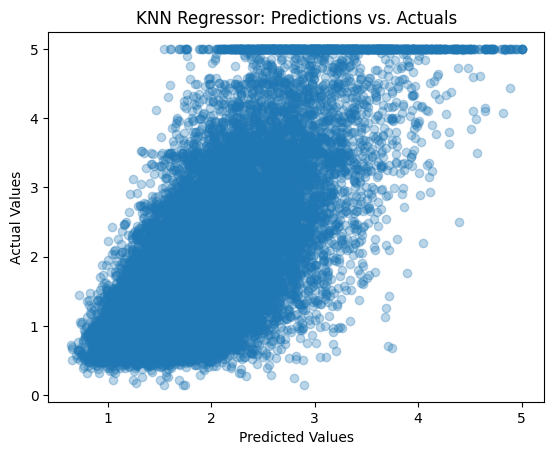

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor

# 1. Load the active dataset
X, y = fetch_california_housing(return_X_y=True)

# 2. Fit the KNN model and make predictions
mod = KNeighborsRegressor().fit(X, y)
pred = mod.predict(X)

# 3. Scatter plot: Predicted vs. Actual values
plt.scatter(pred, y, alpha=0.3)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("KNN Regressor: Predictions vs. Actuals")
plt.show()

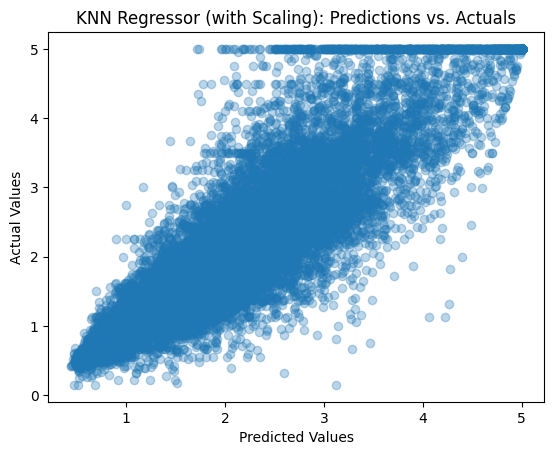

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Load the active dataset
X, y = fetch_california_housing(return_X_y=True)

# 2. Build the pipeline (Scaling -> Model)
pipe = Pipeline([("scale", StandardScaler()), ("model", KNeighborsRegressor())])

# 3. Fit the pipeline and make predictions
pred = pipe.fit(X, y).predict(X)

# 4. Plot predictions vs actuals
plt.scatter(pred, y, alpha=0.3)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("KNN Regressor (with Scaling): Predictions vs. Actuals")
plt.show()

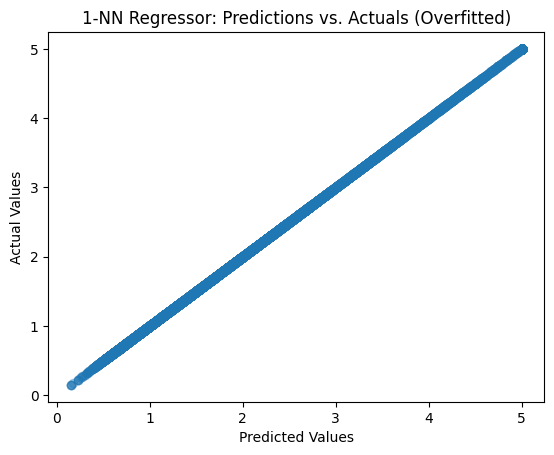

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Load the active dataset
X, y = fetch_california_housing(return_X_y=True)

# 2. Build the pipeline with 1-NN
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=1))
])

# 3. Fit the pipeline and make predictions
pred = pipe.fit(X, y).predict(X)

# 4. Plot predictions vs actuals
plt.scatter(pred, y, alpha=0.3)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("1-NN Regressor: Predictions vs. Actuals (Overfitted)")
plt.show()

In [11]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Load the active dataset
X, y = fetch_california_housing(return_X_y=True)

# 2. Define the pipeline
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())
])

# 3. Set up the Grid Search
mod = GridSearchCV(
    estimator=pipe,
    param_grid={"model__n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
    cv=3,
)

# 4. Fit the grid search
mod.fit(X, y)

# 5. View the results in a DataFrame
results_df = pd.DataFrame(mod.cv_results_)
print(results_df[["param_model__n_neighbors", "mean_test_score", "rank_test_score"]])

   param_model__n_neighbors  mean_test_score  rank_test_score
0                         1         0.327423               10
1                         2         0.465544                9
2                         3         0.511827                8
3                         4         0.535041                7
4                         5         0.547414                6
5                         6         0.555251                5
6                         7         0.559979                4
7                         8         0.563972                3
8                         9         0.565588                2
9                        10         0.567522                1


In [12]:
pd.DataFrame(mod.cv_results_)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.028183,0.007447,0.482303,0.127469,1,{'model__n_neighbors': 1},0.324068,0.334830,0.323371,0.327423,0.005245,10
1,0.018270,0.000207,0.426566,0.035047,2,{'model__n_neighbors': 2},0.468788,0.503457,0.424388,0.465544,0.032361,9
2,0.018293,0.000160,0.454481,0.045808,3,{'model__n_neighbors': 3},0.518547,0.543340,0.473595,0.511827,0.028867,8
3,0.018147,0.000084,0.469962,0.039315,4,{'model__n_neighbors': 4},0.540323,0.564974,0.499827,0.535041,0.026857,7
4,0.024897,0.006554,0.662218,0.184163,5,{'model__n_neighbors': 5},0.551149,0.579313,0.511781,0.547414,0.027696,6
5,0.031167,0.000423,0.747321,0.135839,6,{'model__n_neighbors': 6},0.558435,0.586185,0.521134,0.555251,0.026652,5
6,0.020613,0.002260,0.524316,0.048921,7,{'model__n_neighbors': 7},0.564207,0.590509,0.525223,0.559979,0.026820,4
7,0.018354,0.000298,0.556573,0.043207,8,{'model__n_neighbors': 8},0.568637,0.593942,0.529337,0.563972,0.026580,3
8,0.020648,0.003763,0.550770,0.035327,9,{'model__n_neighbors': 9},0.571972,0.594863,0.529928,0.565588,0.026891,2
9,0.018196,0.000188,0.562977,0.035513,10,{'model__n_neighbors': 10},0.573760,0.595831,0.532973,0.567522,0.026038,1
